In [1]:
import sys
sys.path.insert(0, "../src")
from data_cleaner import DataCleaner
from encoder import TargetEncoder
from sampler import oversample
from evaluator import evaluate_model
from run import run

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline


pd.set_option('display.max_columns', None) # show full dataframe


In [2]:
# import data
X = pd.read_csv("../data/training_set_values.csv")
y = pd.read_csv("../data/training_set_labels.csv")

# split data into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y)

train_data = pd.merge(X_train, y_train, on="id")
test_data = pd.merge(X_test, y_test, on="id")

In [3]:
len(train_data), len(test_data)

(44550, 14850)

In [4]:
# clean train data

cleaner = DataCleaner()
cleaned_data = cleaner.preprocess(train_data)

X_train = cleaned_data.drop(columns=["status_group", "id"])
y_train = cleaned_data["status_group"]


2025-11-27 16:41:04,290 - INFO - Removed -8 invalid rows (negative pump_age). Remaining rows: 44542
2025-11-27 16:41:04,296 - INFO - Data cleaning completed.


In [5]:
# clean train data

cleaner = DataCleaner()
cleaned_data = cleaner.preprocess(test_data)

X_test = cleaned_data.drop(columns=["status_group", "id"])
y_test = cleaned_data["status_group"]

y_test = TargetEncoder().fit_transform(y_test)

2025-11-27 16:41:04,379 - INFO - Removed -1 invalid rows (negative pump_age). Remaining rows: 14849
2025-11-27 16:41:04,383 - INFO - Data cleaning completed.


### Create pipeline (Encoding -> Model and hyperparemter setting) and train model

In [6]:
# define encoding stream for features 
cat_cols = ["quantity_group", "region", "payment_type",
            "extraction_type_class", "management", "quality_group"]

num_cols = ["pump_age"]


categorical_transformer = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

# define the model and controlable parameters
param_dist = {
  'n_estimators': [435, 436, 437, 438, 439, 440],
  'max_depth': [13, 14, 15, 16, 17],
  'min_samples_split': [7, 8, 9, 10, 11],
  'min_samples_leaf': [1, 2, 3, 4, 5]
}


# encode
X_train = preprocessor.fit_transform(X_train)
print(X_train.shape)

# encode target value separately
y_train = TargetEncoder().fit_transform(y_train)

# oversample
X_train, y_train = oversample(X_train, y_train, method="smote")

print(len(X_train), len(y_train))

# Create a random forest classifier
classifier = RandomForestClassifier(random_state=42, n_jobs=-1)



# Create the encoding and training pipeline
# pipeline = make_pipeline([
#     ("encode", preprocessor),
#     ("model", classifier)
# ])

# Create the encoding and training pipeline
# pipeline = make_pipeline(preprocessor,
#                          random_search)


random_search = RandomizedSearchCV(
  classifier, param_distributions=param_dist,
  n_iter=10, cv=5, scoring='accuracy',
  n_jobs=-1, random_state=42, return_train_score=True,
  verbose=3, error_score='raise'
)



(44542, 59)
Oversample with SMOTE
Before Oversampling -> After Oversampling
functional:  24076 -> 24076
non functional: 17224 -> 24076
functional needs repair: 3242 -> 24076
72228 72228


In [7]:
# train model
random_search.fit(X_train, y_train.ravel())

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [13, 14, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [7, 8, ...], 'n_estimators': [435, 436, ...]}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,'raise'


In [24]:
import pickle

# save
with open('../output/checkpoint/3_median.pkl','wb') as f:
    pickle.dump(random_search,f)

In [9]:
# import pickle

# # save
# with open('../output/checkpoint/preprocessor.pkl','wb') as f:
#     pickle.dump(preprocessor,f)

### Test and interpret model

In [10]:
# import pickle
# # load
# with open('../output/checkpoint/1.pkl', 'rb') as f:
#     checkpoint = pickle.load(f)

In [11]:
X_test_encoded = preprocessor.fit_transform(X_test)

In [12]:
prediction = random_search.predict(X_test_encoded)

In [13]:
prediction.shape

(14849,)

### Interpret model

In [14]:

importances = random_search.best_estimator_.feature_importances_

feat_imp = pd.DataFrame({
    "feature": preprocessor.get_feature_names_out(),
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp



,feature,importance
0,cat__quantity_group_dry,0.154012
58,num__pump_age,0.094078
36,cat__extraction_type_class_other,0.069408
33,cat__extraction_type_class_gravity,0.058642
1,cat__quantity_group_enough,0.049409
8,cat__region_Iringa,0.037343
10,cat__region_Kigoma,0.034657
2,cat__quantity_group_insufficient,0.034339
28,cat__payment_type_never pay,0.033607
34,cat__extraction_type_class_handpump,0.032929


In [15]:
import numpy as np

prefixes = ["cat_quantity_group", "cat_region", "cat_payment_type",
            "cat_extraction_type_class", "cat_management", "cat_quality_group",
            "cat_pump_age"]


# grouper = [next(p for p in prefixes if p in c) for c in feat_imp["feature"].to_list()]

In [16]:
res = pd.DataFrame.from_dict(random_search.cv_results_)
res



,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,101.856195,2.267792,3.068721,1.185789,437,11,2,16,"{'n_estimators': 437, 'min_samples_split': 11,...",0.700194,0.749135,0.746643,0.742056,0.751956,0.737997,0.019179,2,0.767159,0.754629,0.755529,0.758026,0.751449,0.757359,0.005333
1,98.905969,3.471802,3.430476,1.497507,438,11,2,15,"{'n_estimators': 438, 'min_samples_split': 11,...",0.695348,0.743597,0.738890,0.735410,0.745379,0.731725,0.018523,7,0.758160,0.748641,0.747517,0.749494,0.744060,0.749574,0.004674
2,93.667077,0.470828,2.319052,0.213589,436,9,5,13,"{'n_estimators': 436, 'min_samples_split': 9, ...",0.681019,0.719438,0.716323,0.715957,0.717965,0.710140,0.014614,10,0.730556,0.719013,0.718788,0.722531,0.716716,0.721521,0.004889
3,94.537750,0.937608,3.785459,0.614195,439,8,4,14,"{'n_estimators': 439, 'min_samples_split': 8, ...",0.688703,0.730652,0.724214,0.724195,0.731256,0.719804,0.015842,8,0.742532,0.730262,0.727528,0.733901,0.728571,0.732559,0.005436
4,94.895476,2.794066,3.690534,1.727227,440,11,5,14,"{'n_estimators': 440, 'min_samples_split': 11,...",0.685865,0.726291,0.722276,0.721288,0.722811,0.715706,0.015016,9,0.739971,0.725312,0.727130,0.729436,0.723188,0.729007,0.005855
5,101.992335,0.767227,2.619406,0.700342,437,10,3,17,"{'n_estimators': 437, 'min_samples_split': 10,...",0.703517,0.751350,0.746712,0.742471,0.753271,0.739464,0.018361,1,0.768059,0.755339,0.753885,0.756884,0.750948,0.757023,0.005855
6,99.715545,3.064197,3.897224,2.183126,435,8,2,15,"{'n_estimators': 435, 'min_samples_split': 8, ...",0.696248,0.743389,0.739305,0.735064,0.747525,0.732306,0.018500,5,0.761241,0.747793,0.747880,0.750532,0.745323,0.750554,0.005592
7,100.779924,0.763173,2.873238,0.336336,440,7,1,14,"{'n_estimators': 440, 'min_samples_split': 7, ...",0.700886,0.742974,0.739374,0.735756,0.747664,0.733331,0.016694,4,0.764044,0.751687,0.751982,0.753284,0.746483,0.753496,0.005763
8,99.145156,2.335976,4.147321,1.517477,435,10,3,16,"{'n_estimators': 435, 'min_samples_split': 10,...",0.700748,0.744635,0.740620,0.738941,0.744410,0.733871,0.016705,3,0.762954,0.748174,0.746945,0.751519,0.743627,0.750644,0.006653
9,73.433049,34.654309,2.184229,0.906287,439,9,5,17,"{'n_estimators': 439, 'min_samples_split': 9, ...",0.698809,0.742143,0.741105,0.735341,0.743579,0.732195,0.016926,6,0.758921,0.743380,0.744055,0.747348,0.741689,0.747079,0.006200


<Axes: >

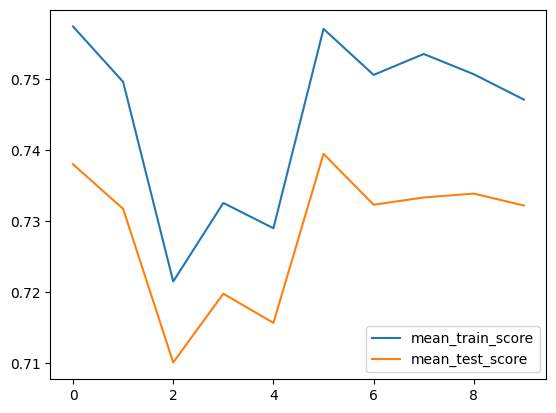

In [17]:
res["mean_train_score"].plot(kind="line", legend=True)
res["mean_test_score"].plot(kind="line", legend=True)

                         precision    recall  f1-score   support

         non functional       0.81      0.65      0.72      5595
functional needs repair       0.22      0.62      0.32      1075
             functional       0.78      0.70      0.74      8179

               accuracy                           0.67     14849
              macro avg       0.60      0.66      0.59     14849
           weighted avg       0.75      0.67      0.70     14849



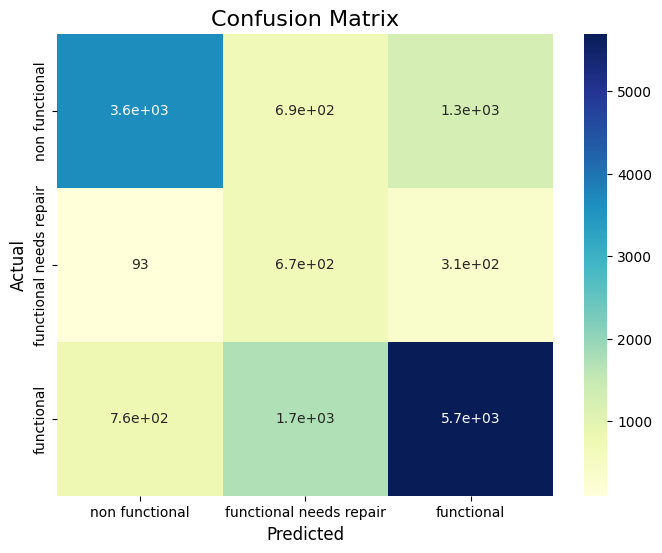

In [18]:
list_prediction = prediction.tolist()
list_y_test = y_test.tolist()

evaluate_model(list_y_test, list_prediction)

### try with all data

In [19]:
all_data = pd.merge(X, y, on="id")

In [20]:

clean = DataCleaner()
cleaned_all_data = clean.preprocess(all_data)

2025-11-27 16:52:59,759 - INFO - Removed -9 invalid rows (negative pump_age). Remaining rows: 59391
2025-11-27 16:52:59,769 - INFO - Data cleaning completed.


In [21]:
X_all = cleaned_all_data.drop("status_group", axis=1)
y_all = cleaned_all_data["status_group"]

In [22]:
X_all = preprocessor.fit_transform(X_all)
y_all = TargetEncoder().fit_transform(y_all)

In [25]:
prediction_all = random_search.predict(X_all)

                         precision    recall  f1-score   support

         non functional       0.83      0.66      0.74     22819
functional needs repair       0.24      0.67      0.35      4317
             functional       0.79      0.71      0.75     32255

               accuracy                           0.69     59391
              macro avg       0.62      0.68      0.61     59391
           weighted avg       0.77      0.69      0.72     59391



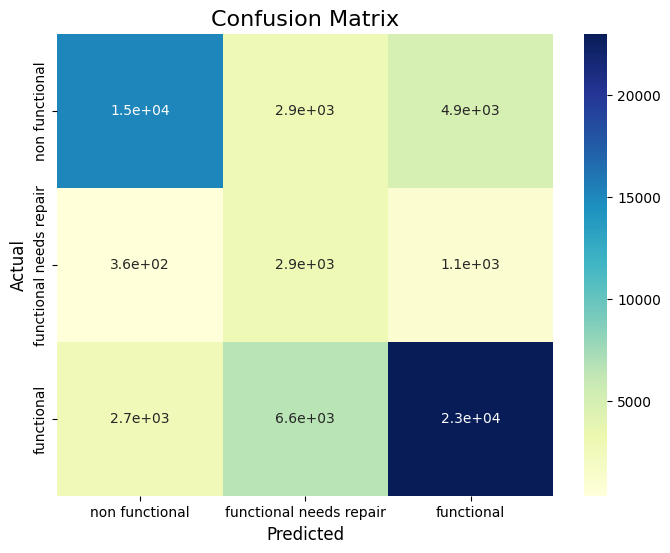

In [26]:
list_prediction_all = prediction_all.tolist()
list_y_all = y_all.tolist()

evaluate_model(list_y_all, list_prediction_all)